# Wrocław metro - wariant flood-safe

Ten notebook jest osobnym wariantem planowania, w którym tereny zalewowe/MZP są traktowane jako twarde ograniczenie. Popyt z obszarów zagrożenia jest przenoszony do najbliższej bezpiecznej ziemi, kandydaci na kotwice są odsuwani od MZP, a stacje/wejścia leżące w dowolnym poligonie zagrożenia powodziowego są usuwane z wyniku.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

import wro_metro as wm

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 120
PROJECT_ROOT

WindowsPath('C:/Users/sila6/Code/wro-metro')

## Założenia wariantu

- Tunel/korytarz może przecinać MZP, więc nie wycinamy geometrii linii z mapy.
- Twardy zakaz dotyczy lokalizacji stacji i wejść do metra na terenach zalewowych.
- Popyt z poligonów MZP jest przenoszony do najbliższej bezpiecznej ziemi.
- Po wyznaczeniu scenariusza wszystkie stacje/wejścia wewnątrz MZP są usuwane, nawet jeśli oznacza to mniej niż 21 przystanków na danej nitce.
- Linia jest przycinana do pierwszej i ostatniej pozostawionej stacji. Główny wynik przycina ją do skrajnych stacji leżących w granicy Wrocławia.

In [2]:
config = wm.MetroConfig(
    cost_per_km_mln=650.0,
    flood_cost_multiplier=2.0,
    walk_radius_m=1_100.0,
    forbidden_penalty_per_km=60_000.0,
    max_forbidden_km=None,
    forbidden_excess_penalty_per_km=0.0,
    outside_city_penalty_per_km=500_000.0,
    max_outside_city_km=0.15,
    outside_city_excess_penalty_per_km=5_000_000.0,
    geology_penalty_per_km=40_000.0,
    high_geology_factor_threshold=1.50,
    high_geology_penalty_per_km=120_000.0,
    anchor_geology_penalty_per_excess=35_000.0,
    anchor_high_geology_penalty=25_000.0,
    station_geology_penalty_per_excess=12_000.0,
    station_high_geology_penalty=8_000.0,
    station_geology_score_factor=1.40,
    river_crossing_bonus_per_km=600.0,
    transfer_bonus_per_interchange=35_000.0,
    interchange_radius_m=450.0,
    line_overlap_penalty_per_km=350_000.0,
    parallel_line_buffer_m=900.0,
    candidate_existing_line_buffer_m=900.0,
    candidate_radial_overlap_limit_km=1.50,
    parallel_overlap_angle_deg=35.0,
    max_line_overlap_km=0.75,
    line_overlap_excess_penalty_per_km=5_000_000.0,
    arm_reuse_angle_deg=35.0,
    arm_reuse_penalty=10_000_000.0,
    residual_coverage_multiplier=1.35,
    relocation_search_radius_m=3_500.0,
    relocation_step_m=25.0,
    station_risk_buffer_m=260.0,
    candidate_catchment_radius_m=1_600.0,
    central_anchor_radius_m=3_000.0,
    min_central_anchor_candidates=8,
    max_central_anchor_share=0.32,
    min_regional_anchor_candidates=8,
    min_directional_anchor_candidates_per_sector=5,
    route_anchor_count=6,
    max_turn_angle_deg=45.0,
    hard_max_turn_angle_deg=85.0,
    turn_penalty_per_degree=1_500.0,
    minimum_curve_radius_m=450.0,
    curve_radius_penalty_per_m=90.0,
    corridor_detour_ratio_limit=1.35,
    corridor_detour_penalty_per_ratio=90_000.0,
    corridor_backtrack_penalty_per_km=45_000.0,
    adaptive_station_placement=True,
    station_min_spacing_m=800.0,
    station_max_spacing_m=1_700.0,
    station_candidate_step_m=125.0,
    station_flood_score_factor=0.0,
    station_water_buffer_m=90.0,
    station_water_score_factor=0.02,
    station_terminal_flex_m=1_500.0,
    station_anchor_bonus_radius_m=260.0,
    station_anchor_bonus=7_500.0,
)

raw_dir = PROJECT_ROOT / "data" / "raw"
population_layer = wm.load_wroclaw_demography(raw_dir, year=2025, unit="REJSTAT")
demand_areas = wm.demand_areas_from_polygons(population_layer, weight_col="SUMA")
demand_raw = wm.to_demand_points(population_layer, weight_col="SUMA")
demand_raw["name"] = "rejon_" + demand_raw["REJON"].astype(str)

osiedla = wm.load_wroclaw_osiedla(raw_dir)
city_boundary = wm.city_boundary_from_layer(osiedla, name="Wroclaw boundary from SIP districts")
centre_area = osiedla[osiedla["NAZWAOSIED"].eq("Stare Miasto")].copy()
centres = wm.demo_centres()
stare_miasto_point = centre_area.geometry.iloc[0].representative_point()
mask = centres["role"].eq("required_city_centre")
centres.loc[mask, "name"] = "Stare Miasto"
centres.loc[mask, "geometry"] = [stare_miasto_point]

flood_zones = wm.load_forbidden_zones_from_raw(raw_dir)
if flood_zones is None or flood_zones.empty:
    raise FileNotFoundError("Ten wariant wymaga realnej warstwy MZP/flood_zones w data/raw.")

water_crossings = wm.load_water_crossing_layer(raw_dir)
geology = wm.load_geology_cost_layer_from_raw(raw_dir)
if geology is None:
    geology = gpd.GeoDataFrame({"cost_factor": []}, geometry=[], crs=demand_raw.crs)

regional_clusters = wm.regional_clusters_from_demand_areas(demand_areas, k=8)
regional_centres = wm.regional_centres_from_clusters(regional_clusters)

print(f"Liczba rejonów popytu: {len(demand_raw)}")
print(f"Liczba poligonów MZP: {len(flood_zones)}")
print("Tunel może przechodzić przez MZP; twardy zakaz dotyczy stacji i wejść.")

Liczba rejonów popytu: 641
Liczba poligonów MZP: 87
Tunel może przechodzić przez MZP; twardy zakaz dotyczy stacji i wejść.


In [3]:
demand = wm.relocate_demand_to_safe_land(demand_raw, flood_zones, config=config)
flood_union = flood_zones.geometry.unary_union

relocation_report = pd.DataFrame({
    "metric": [
        "punkty popytu przed relokacją w MZP",
        "punkty popytu po relokacji w MZP",
        "punkty przeniesione",
        "maksymalne przesunięcie [m]",
    ],
    "value": [
        int(demand_raw.geometry.apply(lambda point: bool(flood_union.covers(point))).sum()),
        int(demand.geometry.apply(lambda point: bool(flood_union.covers(point))).sum()),
        int(demand["was_relocated"].sum()),
        float(pd.to_numeric(demand["relocated_m"], errors="coerce").max()),
    ],
})
relocation_report

C:\Users\sila6\AppData\Local\Temp\ipykernel_26412\1953371690.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  flood_union = flood_zones.geometry.unary_union


,metric,value
0,punkty popytu przed relokacją w MZP,138.000000
1,punkty popytu po relokacji w MZP,0.000000
2,punkty przeniesione,138.000000
3,maksymalne przesunięcie [m],2640.406097


In [4]:
candidate_sites = wm.candidate_station_sites(
    demand=demand,
    regional_centres=regional_centres,
    centres=centres,
    forbidden=flood_zones,
    geology=geology,
    water_crossings=water_crossings,
    config=config,
    max_candidates=45,
)

centre_point = candidate_sites.loc[candidate_sites["required"], "geometry"].iloc[0]
candidate_sites[[
    "candidate_id",
    "source",
    "name",
    "candidate_weight",
    "required",
    "direction_sector",
    "anchor_relocated_m",
    "in_flood_zone",
    "in_flood_buffer",
    "distance_to_flood_m",
]].head(20)

,candidate_id,source,name,candidate_weight,required,direction_sector,anchor_relocated_m,in_flood_zone,in_flood_buffer,distance_to_flood_m
0,C001,forced_centre,Stare Miasto,10708.981003,True,north,0.000000,False,False,391.941070
1,C002,regional_centre,regional_0,11756.618733,False,west,0.000000,False,False,1442.591305
2,C003,regional_centre,regional_6,248.945024,False,east,528.304534,True,True,0.000000
3,C004,regional_centre,regional_1,0.000000,False,south,0.000000,False,False,1889.480815
4,C005,regional_centre,regional_3,0.000000,False,south,0.000000,False,False,1030.053222
5,C006,regional_centre,regional_4,0.000000,False,west,404.905880,True,True,0.000000
6,C007,regional_centre,regional_5,0.000000,False,west,3083.125674,True,True,0.000000
7,C008,regional_centre,regional_7,0.000000,False,north,3013.460687,True,True,0.000000
8,C009,demand,rejon_931750,15092.246775,False,south,0.000000,False,False,1434.176996
9,C010,demand,rejon_931910,15021.849938,False,south,0.000000,False,False,1795.541148


In [5]:
raw_scenarios = wm.build_orienteering_scenarios(
    demand=demand,
    candidates=candidate_sites,
    centre=centre_point,
    forbidden=flood_zones,
    geology=geology,
    water_crossings=water_crossings,
    city_boundary=city_boundary,
    base_config=config,
)

scenarios = {
    scenario_id: wm.remove_stations_in_forbidden_zones(scenario, flood_zones)
    for scenario_id, scenario in raw_scenarios.items()
}
scenarios_trimmed_to_stations = {
    scenario_id: wm.trim_scenario_lines_to_station_extent(
        scenario,
        forbidden=flood_zones,
        require_stations_in_city=False,
    )
    for scenario_id, scenario in scenarios.items()
}
scenarios = {
    scenario_id: wm.trim_scenario_lines_to_station_extent(
        scenario,
        city_boundary=city_boundary,
        forbidden=flood_zones,
        require_stations_in_city=True,
    )
    for scenario_id, scenario in scenarios.items()
}

summary = wm.scenario_summary_table(scenarios, demand)
summary.assign(
    length_km=lambda df: df["length_km"].round(1),
    served_share=lambda df: (100 * df["served_share"]).round(1),
    forbidden_km=lambda df: df["forbidden_km"].round(3),
    trimmed_line_tail_km=lambda df: df["trimmed_line_tail_km"].round(3),
    station_flood_zone_count=lambda df: df["station_flood_zone_count"].astype(int),
    removed_flood_station_count=lambda df: df["removed_flood_station_count"].astype(int),
    removed_outside_city_station_count=lambda df: df["removed_outside_city_station_count"].astype(int),
    station_flood_buffer_count=lambda df: df["station_flood_buffer_count"].astype(int),
    outside_city_km=lambda df: df["outside_city_km"].round(2),
    line_overlap_km=lambda df: df["line_overlap_km"].round(2),
    estimated_cost_mln=lambda df: df["estimated_cost_mln"].round(0),
)

,scenario,lines,stations,length_km,avg_station_spacing_m,min_station_spacing_m,max_station_spacing_m,served_weight,served_share,avg_geology_factor,geology_excess_km,high_geology_km,anchor_geology_penalty,station_geology_penalty,forbidden_km,forbidden_excess_km,forbidden_excess_penalty,station_flood_zone_count,removed_flood_station_count,removed_outside_city_station_count,trimmed_line_tail_km,station_water_zone_count,station_flood_buffer_count,station_water_buffer_count,water_crossing_km,outside_city_km,outside_city_penalty,outside_city_excess_km,outside_city_excess_penalty,transfer_count,transfer_score,line_overlap_km,line_overlap_excess_km,line_overlap_excess_penalty,arm_reuse_penalty,forced_southern_line_count,turn_penalty,max_turn_angle_deg,mean_turn_angle_deg,sharp_turn_count,curve_radius_violation_m,corridor_detour_ratio,corridor_backtrack_km,corridor_shape_penalty,base_cost_mln,flood_extra_cost_mln,estimated_cost_mln
0,1 linia - orienteering,1,20,21.1,1111.842105,875.0,2500.0,88724.225576,15.7,1.205625,4.329983,1.842546,24500.0,64000.0,4.418,0.0,0.0,0,1,0,1.975,0,4,2,0.396269,0.0,0.0,0.0,0.0,0,0.0,0.00,0.000000,0.000000e+00,0.000000e+00,0,140590.296847,79.194241,49.008097,3,0.0,1.177815,0.0,0.0,16554.738281,2871.697151,19426.0
1,2 linie - orienteering,2,39,40.5,1094.594595,875.0,2500.0,131419.816892,23.3,1.225625,9.608411,3.185658,42000.0,124200.0,9.401,0.0,0.0,0,2,1,5.700,0,10,5,0.919484,0.0,0.0,0.0,0.0,3,105000.0,7.41,6.662494,3.331247e+07,2.593601e+06,0,164856.531489,79.194241,38.374736,4,0.0,1.185635,0.0,0.0,32241.828125,6110.357941,38352.0
2,3 linie - orienteering,3,58,58.6,1065.909091,875.0,2500.0,175001.543078,31.0,1.217708,13.884971,3.980065,52500.0,167400.0,12.315,0.0,0.0,0,2,3,10.675,0,15,11,1.780639,0.0,0.0,0.0,0.0,6,210000.0,12.93,11.432369,5.716184e+07,9.331226e+06,0,164856.531489,79.194241,33.209908,4,0.0,1.151353,0.0,0.0,46401.417969,8004.687809,54406.0


In [6]:
validation_rows = []
city_union = city_boundary.geometry.unary_union
for scenario_id, scenario in scenarios.items():
    lines, stations = wm.scenario_geodataframes(scenario)
    unsafe_station_count = int(stations.geometry.apply(lambda point: bool(flood_union.covers(point))).sum())
    outside_city_station_count = int((~stations.geometry.apply(lambda point: bool(city_union.covers(point)))).sum())
    validation_rows.append({
        "scenario_id": scenario_id,
        "stations_after_filter": len(stations),
        "unsafe_stations_after_filter": unsafe_station_count,
        "outside_city_stations_after_filter": outside_city_station_count,
        "trimmed_line_tail_km": float(lines.get("trimmed_line_tail_km", pd.Series(dtype=float)).sum()),
        "corridor_flood_km_reported": float(lines["forbidden_km"].sum()),
        "removed_flood_station_count": int(lines.get("removed_flood_station_count", pd.Series(dtype=int)).sum()),
        "removed_outside_city_station_count": int(lines.get("removed_outside_city_station_count", pd.Series(dtype=int)).sum()),
    })

pd.DataFrame(validation_rows)

C:\Users\sila6\AppData\Local\Temp\ipykernel_26412\1256381370.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_union = city_boundary.geometry.unary_union


,scenario_id,stations_after_filter,unsafe_stations_after_filter,outside_city_stations_after_filter,trimmed_line_tail_km,corridor_flood_km_reported,removed_flood_station_count,removed_outside_city_station_count
0,1,20,0,0,1.975,4.417996,1,0
1,2,39,0,0,5.700,9.400551,2,1
2,3,58,0,0,10.675,12.314904,2,3


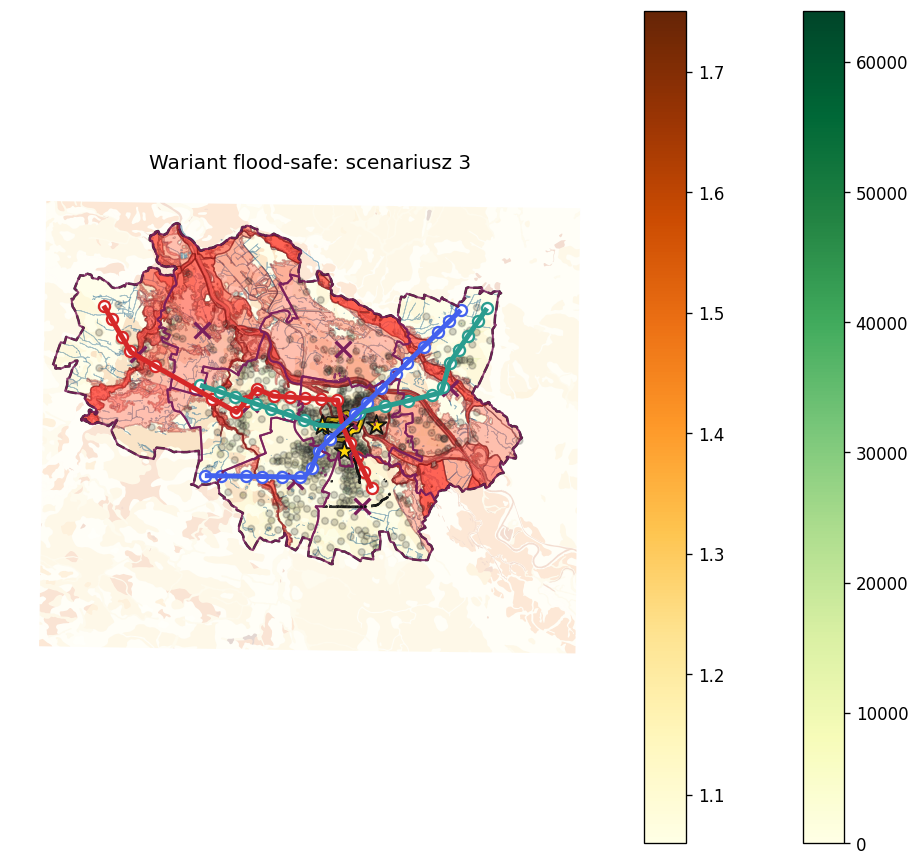

In [7]:
selected_scenario = "3"

fig, ax = wm.plot_scenario(
    demand=demand,
    forbidden=flood_zones,
    scenario=scenarios[selected_scenario],
    centres=centres,
    regional_centres=regional_centres,
    regional_clusters=regional_clusters,
    geology=geology,
    demand_areas=demand_areas,
    water_crossings=water_crossings,
    city_boundary=city_boundary,
    centre_area=centre_area,
    figsize=(10, 9),
)
ax.set_title("Wariant flood-safe: scenariusz 3")
plt.show()

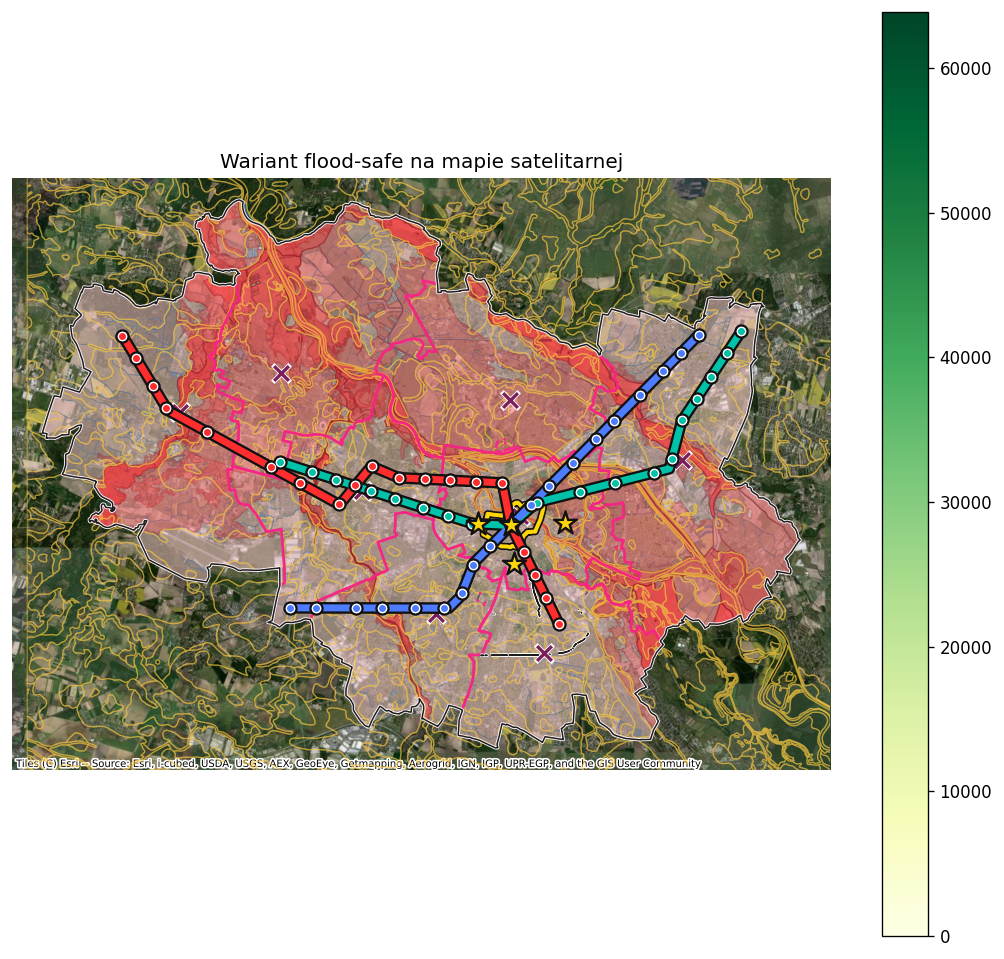

In [8]:
fig, ax = wm.plot_scenario_satellite(
    demand=demand,
    forbidden=flood_zones,
    scenario=scenarios[selected_scenario],
    centres=centres,
    regional_centres=regional_centres,
    regional_clusters=regional_clusters,
    geology=geology,
    demand_areas=demand_areas,
    water_crossings=water_crossings,
    city_boundary=city_boundary,
    centre_area=centre_area,
    figsize=(11, 10),
)
ax.set_title("Wariant flood-safe na mapie satelitarnej")
plt.show()

In [9]:
lines, stations = wm.scenario_geodataframes(scenarios[selected_scenario])
stations_wgs = stations.to_crs(4326).copy()
stations_wgs["lon"] = stations_wgs.geometry.x
stations_wgs["lat"] = stations_wgs.geometry.y
stations_wgs[[
    "line_id",
    "station_code",
    "distance_m",
    "station_placement",
    "in_station_flood_zone",
    "in_station_flood_buffer",
    "lon",
    "lat",
]].head(80)

,line_id,station_code,distance_m,station_placement,in_station_flood_zone,in_station_flood_buffer,lon,lat
0,1,L01-S01,0.0,adaptive_dp,False,False,16.846351,51.168728
1,1,L01-S02,875.0,adaptive_dp,False,False,16.852853,51.162009
2,1,L01-S03,2000.0,adaptive_dp,False,False,16.861209,51.153369
3,1,L01-S04,2875.0,adaptive_dp,False,False,16.867706,51.146649
4,1,L01-S05,4500.0,adaptive_dp,False,True,16.887558,51.139294
5,1,L01-S06,7000.0,adaptive_dp,False,True,16.918878,51.128493
6,1,L01-S07,8125.0,adaptive_dp,False,True,16.932968,51.123630
7,1,L01-S08,9625.0,adaptive_dp,False,False,16.951749,51.117143
8,1,L01-S09,10500.0,adaptive_dp,False,False,16.959792,51.122938
9,1,L01-S10,11375.0,adaptive_dp,False,False,16.967847,51.128765
